In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics 
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler,MinMaxScaler ,LabelEncoder
from xgboost import XGBClassifier
import catboost as ctb
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, confusion_matrix,recall_score,precision_score

In [3]:
import shap
from matplotlib import pyplot as plt
import seaborn as sns

# Dataset Read

In [4]:
data  = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [5]:
df = data.copy()

In [6]:
df = df.rename(columns={'family_history_with_overweight': 'family_history'})

In [7]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'NObeyesdad'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  NObeyesdad      2111 non-null   object 
dtypes: float64(8), object(9)
memory u

# Unique Value of Object Attribute

In [ ]:
for col in data.select_dtypes('object'):
    print(f'{col:-<40} {data[col].unique()}')

In [ ]:
print(df['NObeyesdad'].value_counts())
print("   ")
print(df['NObeyesdad'].value_counts(normalize=True))

In [ ]:
for col in data.select_dtypes('float64'):
    print(col)

In [9]:
def split(df):
    trainset, testset = train_test_split(df, test_size=0.20, random_state=0,stratify=df['NObeyesdad'])
    return trainset,testset

In [10]:
def encodage(df):
    code = {'yes':1,
            'no':0,
            'Female':1,
            'Male':0,
            'Sometimes':1,
            'Frequently':2,
            'Always':3,
            'Automobile':1,
            'Motorbike':2,
            'Bike':3, 
            'Public_Transportation':4,
            'Walking':5, 
            'Insufficient_Weight':0,
            'Normal_Weight':1 ,
            'Overweight_Level_I':2 ,
            'Overweight_Level_II':3,
            'Obesity_Type_I':4,            
            'Obesity_Type_II':5,
            'Obesity_Type_III':6
           }
    for col in df.select_dtypes('object').columns:
        df.loc[:,col] = df[col].map(code)
    return df

In [11]:
def preprocessing(df):
    df = encodage(df)
    X = df.drop('NObeyesdad',axis = 1)
    Y = df['NObeyesdad']
    return X, Y

In [12]:
def GetReadyForML (df):
    trainset, testset = split (df)
    X_train, Y_train = preprocessing(trainset)
    X_test, Y_test = preprocessing(testset)
    return X_train, Y_train, X_test, Y_test

In [13]:
def evaluation(model):
    
    model.fit(X_train, Y_train)
    ypred = model.predict(X_test)
    model_acc = accuracy_score(Y_test, ypred)
    f1=f1_score(Y_test, ypred,average='weighted')
    re=recall_score(Y_test, ypred,average='weighted')
    pe=precision_score(Y_test, ypred,average='weighted')
    print('Test Data') 
    sns.heatmap(confusion_matrix(Y_test, ypred), annot=True)
    
    print(classification_report(Y_test, ypred))
    print('Accuracy : ' + str(model_acc))
    print('F1_score : ' + str(f1))
    print('Recall : ' + str(re))
    print('pression : ' + str(pe))
#     #'''
#     ypred2 = model.predict(X_train)
#     model_acc2 = accuracy_score(Y_train, ypred2)
#     f1_=f1_score(Y_train, ypred2,average='weighted')
#     re_=recall_score(Y_train, ypred2,average='weighted')
#     pe_=precision_score(Y_train, ypred2,average='weighted')
#     print('Train Data') 
#     print(confusion_matrix(Y_train, ypred2))  
#     print(classification_report(Y_train, ypred2))
#     print('Accuracy : ' + str(model_acc2))
#     print('F1_score : ' + str(f1_))
#     print('Recall : ' + str(re_))
#     print('Pression : ' + str(pe_))
#    # '''
#     return model_acc

In [14]:
def catboost():
#     df = data.copy()
#     X_train, Y_train, X_test, Y_test = GetReadyForML(df)
    model_CBC = ctb.CatBoostClassifier()
    model_CBC.fit(X_train, Y_train)
    predicted_y = model_CBC.predict(X_test)
    expected_y  = Y_test
    print(metrics.classification_report(expected_y, predicted_y))
    print(metrics.confusion_matrix(expected_y, predicted_y))
    explainer = shap.TreeExplainer(model_CBC)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar")

# Ml algo declare

In [15]:
xg = XGBClassifier()
dt = DecisionTreeClassifier(random_state=0)
ad = AdaBoostClassifier(random_state=0)
knn = KNeighborsClassifier()
gb = GradientBoostingClassifier()
lg = LogisticRegression()
rf=RandomForestClassifier()

In [16]:
X_train, Y_train, X_test, Y_test = GetReadyForML(df)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Learning rate set to 0.081268
0:	learn: 1.7425688	total: 184ms	remaining: 3m 3s
1:	learn: 1.6072024	total: 201ms	remaining: 1m 40s
2:	learn: 1.4876605	total: 216ms	remaining: 1m 11s
3:	learn: 1.3771548	total: 229ms	remaining: 57.1s
4:	learn: 1.3008707	total: 242ms	remaining: 48.2s
5:	learn: 1.2393065	total: 255ms	remaining: 42.2s
6:	learn: 1.1804442	total: 267ms	remaining: 37.8s
7:	learn: 1.1161910	total: 279ms	remaining: 34.6s
8:	learn: 1.0595066	total: 292ms	remaining: 32.2s
9:	learn: 1.0071656	total: 305ms	remaining: 30.2s
10:	learn: 0.9628547	total: 318ms	remaining: 28.5s
11:	learn: 0.9182214	total: 330ms	remaining: 27.2s
12:	learn: 0.8799367	total: 343ms	remaining: 26s
13:	learn: 0.8436522	total: 358ms	remaining: 25.2s
14:	learn: 0.8133694	total: 373ms	remaining: 24.5s
15:	learn: 0.7866169	total: 385ms	remaining: 23.7s
16:	learn: 0.7606817	total: 402ms	remaining: 23.3s
17:	learn: 0.7355479	total: 416ms	remaining: 22.7s
18:	learn: 0.7142625	total: 429ms	remaining: 22.2s
19:	learn: 

167:	learn: 0.1100037	total: 2.6s	remaining: 12.9s
168:	learn: 0.1089214	total: 2.62s	remaining: 12.9s
169:	learn: 0.1083628	total: 2.63s	remaining: 12.8s
170:	learn: 0.1075407	total: 2.64s	remaining: 12.8s
171:	learn: 0.1069899	total: 2.65s	remaining: 12.8s
172:	learn: 0.1065526	total: 2.67s	remaining: 12.8s
173:	learn: 0.1060681	total: 2.68s	remaining: 12.7s
174:	learn: 0.1055193	total: 2.7s	remaining: 12.7s
175:	learn: 0.1050250	total: 2.71s	remaining: 12.7s
176:	learn: 0.1042505	total: 2.73s	remaining: 12.7s
177:	learn: 0.1035460	total: 2.75s	remaining: 12.7s
178:	learn: 0.1031814	total: 2.76s	remaining: 12.7s
179:	learn: 0.1022994	total: 2.78s	remaining: 12.6s
180:	learn: 0.1019550	total: 2.79s	remaining: 12.6s
181:	learn: 0.1015516	total: 2.81s	remaining: 12.6s
182:	learn: 0.1009147	total: 2.82s	remaining: 12.6s
183:	learn: 0.1005582	total: 2.84s	remaining: 12.6s
184:	learn: 0.0996684	total: 2.86s	remaining: 12.6s
185:	learn: 0.0992681	total: 2.87s	remaining: 12.6s
186:	learn: 0.

337:	learn: 0.0502294	total: 4.97s	remaining: 9.74s
338:	learn: 0.0500723	total: 4.99s	remaining: 9.73s
339:	learn: 0.0497653	total: 5.01s	remaining: 9.72s
340:	learn: 0.0495478	total: 5.02s	remaining: 9.7s
341:	learn: 0.0494389	total: 5.04s	remaining: 9.69s
342:	learn: 0.0493366	total: 5.05s	remaining: 9.68s
343:	learn: 0.0492360	total: 5.07s	remaining: 9.66s
344:	learn: 0.0490048	total: 5.08s	remaining: 9.64s
345:	learn: 0.0488820	total: 5.09s	remaining: 9.62s
346:	learn: 0.0487054	total: 5.1s	remaining: 9.61s
347:	learn: 0.0485920	total: 5.12s	remaining: 9.59s
348:	learn: 0.0484893	total: 5.13s	remaining: 9.57s
349:	learn: 0.0483523	total: 5.19s	remaining: 9.63s
350:	learn: 0.0482017	total: 5.22s	remaining: 9.65s
351:	learn: 0.0479577	total: 5.24s	remaining: 9.64s
352:	learn: 0.0478266	total: 5.25s	remaining: 9.63s
353:	learn: 0.0477034	total: 5.27s	remaining: 9.62s
354:	learn: 0.0475455	total: 5.29s	remaining: 9.6s
355:	learn: 0.0473228	total: 5.3s	remaining: 9.59s
356:	learn: 0.04

497:	learn: 0.0320365	total: 7.51s	remaining: 7.57s
498:	learn: 0.0319781	total: 7.52s	remaining: 7.55s
499:	learn: 0.0319057	total: 7.53s	remaining: 7.53s
500:	learn: 0.0318288	total: 7.55s	remaining: 7.52s
501:	learn: 0.0317624	total: 7.56s	remaining: 7.5s
502:	learn: 0.0316939	total: 7.57s	remaining: 7.48s
503:	learn: 0.0315382	total: 7.59s	remaining: 7.47s
504:	learn: 0.0314209	total: 7.6s	remaining: 7.45s
505:	learn: 0.0313291	total: 7.62s	remaining: 7.43s
506:	learn: 0.0312917	total: 7.63s	remaining: 7.42s
507:	learn: 0.0311786	total: 7.64s	remaining: 7.4s
508:	learn: 0.0310611	total: 7.65s	remaining: 7.38s
509:	learn: 0.0310082	total: 7.67s	remaining: 7.37s
510:	learn: 0.0309353	total: 7.68s	remaining: 7.35s
511:	learn: 0.0308584	total: 7.69s	remaining: 7.33s
512:	learn: 0.0308129	total: 7.7s	remaining: 7.31s
513:	learn: 0.0307441	total: 7.72s	remaining: 7.3s
514:	learn: 0.0307012	total: 7.73s	remaining: 7.28s
515:	learn: 0.0306441	total: 7.74s	remaining: 7.26s
516:	learn: 0.030

659:	learn: 0.0224289	total: 9.69s	remaining: 4.99s
660:	learn: 0.0223705	total: 9.7s	remaining: 4.97s
661:	learn: 0.0223590	total: 9.71s	remaining: 4.96s
662:	learn: 0.0223169	total: 9.73s	remaining: 4.95s
663:	learn: 0.0222444	total: 9.75s	remaining: 4.93s
664:	learn: 0.0222095	total: 9.76s	remaining: 4.92s
665:	learn: 0.0221643	total: 9.78s	remaining: 4.91s
666:	learn: 0.0220995	total: 9.81s	remaining: 4.89s
667:	learn: 0.0220674	total: 9.82s	remaining: 4.88s
668:	learn: 0.0220212	total: 9.84s	remaining: 4.87s
669:	learn: 0.0219730	total: 9.86s	remaining: 4.85s
670:	learn: 0.0219416	total: 9.87s	remaining: 4.84s
671:	learn: 0.0218954	total: 9.88s	remaining: 4.82s
672:	learn: 0.0218608	total: 9.89s	remaining: 4.81s
673:	learn: 0.0218093	total: 9.91s	remaining: 4.79s
674:	learn: 0.0217712	total: 9.92s	remaining: 4.78s
675:	learn: 0.0217294	total: 9.94s	remaining: 4.76s
676:	learn: 0.0216951	total: 9.95s	remaining: 4.75s
677:	learn: 0.0216554	total: 9.97s	remaining: 4.74s
678:	learn: 0

818:	learn: 0.0172924	total: 12.1s	remaining: 2.67s
819:	learn: 0.0172767	total: 12.1s	remaining: 2.66s
820:	learn: 0.0172532	total: 12.1s	remaining: 2.64s
821:	learn: 0.0172245	total: 12.2s	remaining: 2.63s
822:	learn: 0.0172072	total: 12.2s	remaining: 2.62s
823:	learn: 0.0171719	total: 12.2s	remaining: 2.6s
824:	learn: 0.0171366	total: 12.2s	remaining: 2.59s
825:	learn: 0.0171051	total: 12.2s	remaining: 2.58s
826:	learn: 0.0170943	total: 12.2s	remaining: 2.56s
827:	learn: 0.0170521	total: 12.3s	remaining: 2.55s
828:	learn: 0.0170245	total: 12.3s	remaining: 2.53s
829:	learn: 0.0170136	total: 12.3s	remaining: 2.52s
830:	learn: 0.0169983	total: 12.3s	remaining: 2.5s
831:	learn: 0.0169869	total: 12.3s	remaining: 2.49s
832:	learn: 0.0169681	total: 12.4s	remaining: 2.48s
833:	learn: 0.0169034	total: 12.4s	remaining: 2.46s
834:	learn: 0.0168245	total: 12.4s	remaining: 2.45s
835:	learn: 0.0168008	total: 12.4s	remaining: 2.43s
836:	learn: 0.0167794	total: 12.4s	remaining: 2.42s
837:	learn: 0.

980:	learn: 0.0136764	total: 14.5s	remaining: 280ms
981:	learn: 0.0136571	total: 14.5s	remaining: 266ms
982:	learn: 0.0136318	total: 14.5s	remaining: 251ms
983:	learn: 0.0136193	total: 14.5s	remaining: 236ms
984:	learn: 0.0135939	total: 14.5s	remaining: 221ms
985:	learn: 0.0135732	total: 14.5s	remaining: 206ms
986:	learn: 0.0135574	total: 14.6s	remaining: 192ms
987:	learn: 0.0135384	total: 14.6s	remaining: 177ms
988:	learn: 0.0135250	total: 14.6s	remaining: 162ms
989:	learn: 0.0135095	total: 14.6s	remaining: 147ms
990:	learn: 0.0135016	total: 14.6s	remaining: 133ms
991:	learn: 0.0134942	total: 14.6s	remaining: 118ms
992:	learn: 0.0134678	total: 14.6s	remaining: 103ms
993:	learn: 0.0134534	total: 14.6s	remaining: 88.4ms
994:	learn: 0.0134391	total: 14.7s	remaining: 73.7ms
995:	learn: 0.0134192	total: 14.7s	remaining: 58.9ms
996:	learn: 0.0134044	total: 14.7s	remaining: 44.2ms
997:	learn: 0.0133918	total: 14.7s	remaining: 29.4ms
998:	learn: 0.0133740	total: 14.7s	remaining: 14.7ms
999:	l

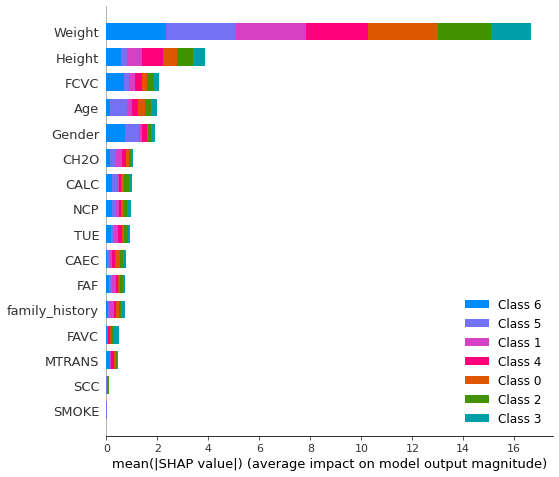

In [17]:
catboost()

Test Data
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.93      0.98      0.96        58
           2       0.95      0.95      0.95        58
           3       0.95      0.97      0.96        58
           4       1.00      0.93      0.96        70
           5       0.97      1.00      0.98        60
           6       1.00      1.00      1.00        65

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423

Accuracy : 0.9716312056737588
F1_score : 0.9716395288044577
Recall : 0.9716312056737588
pression : 0.9723689950310516


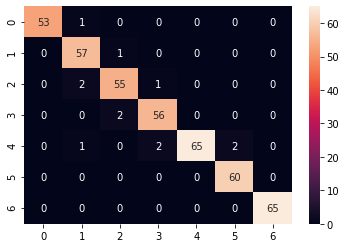

In [18]:
evaluation(rf)

Test Data
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        54
           1       0.84      0.83      0.83        58
           2       0.86      0.93      0.89        58
           3       0.96      0.91      0.94        58
           4       0.92      0.94      0.93        70
           5       0.97      0.93      0.95        60
           6       1.00      1.00      1.00        65

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.93      0.92      0.92       423

Accuracy : 0.9243498817966903
F1_score : 0.9245167493959944
Recall : 0.9243498817966903
pression : 0.925459880661146


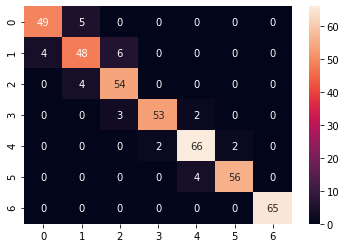

In [19]:
evaluation(dt)

Test Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.93      0.97      0.95        58
           2       0.92      0.93      0.92        58
           3       0.98      0.90      0.94        58
           4       0.96      0.96      0.96        70
           5       0.97      1.00      0.98        60
           6       1.00      1.00      1.00        65

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423

Accuracy : 0.9645390070921985
F1_score : 0.964416181515494
Recall : 0.9645390070921985
pression : 0.964984055797721


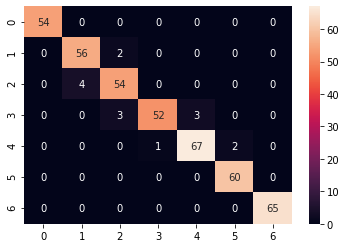

In [20]:
evaluation(gb)

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Test Data
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        54
           1       0.33      0.45      0.38        58
           2       0.40      0.07      0.12        58
           3       0.29      0.81      0.43        58
           4       0.20      0.49      0.28        70
           5       0.00      0.00      0.00        60
           6       0.00      0.00      0.00        65

    accuracy                           0.26       423
   macro avg       0.17      0.26      0.17       423
weighted avg       0.17      0.26      0.17       423

Accuracy : 0.2624113475177305
F1_score : 0.17327128461154692
Recall : 0.2624113475177305
pression : 0.17228643142748737


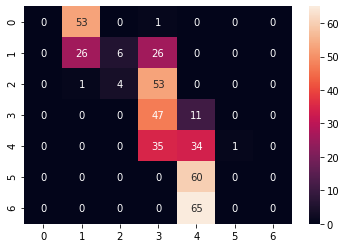

In [21]:
evaluation(ad)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Test Data
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        54
           1       0.50      0.45      0.47        58
           2       0.49      0.45      0.47        58
           3       0.47      0.38      0.42        58
           4       0.55      0.57      0.56        70
           5       0.83      0.90      0.86        60
           6       0.89      1.00      0.94        65

    accuracy                           0.66       423
   macro avg       0.65      0.66      0.65       423
weighted avg       0.65      0.66      0.65       423

Accuracy : 0.6643026004728132
F1_score : 0.6539019440270719
Recall : 0.6643026004728132
pression : 0.6474723331380015


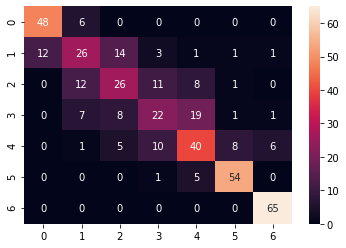

In [22]:
evaluation(lg)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


[19:27:29] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Test Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.98      0.95      0.96        58
           2       0.92      0.98      0.95        58
           3       0.98      0.93      0.96        58
           4       0.99      0.96      0.97        70
           5       0.95      1.00      0.98        60
           6       1.00      1.00      1.00        65

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423

Accuracy : 0.9739952718676123
F1_score : 0.9740097883165323
Recall : 0.97399527186

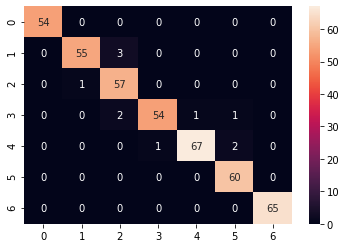

In [23]:
evaluation(xg)

Test Data
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        54
           1       0.91      0.55      0.69        58
           2       0.78      0.91      0.84        58
           3       0.82      0.81      0.82        58
           4       0.81      0.86      0.83        70
           5       0.94      0.85      0.89        60
           6       0.89      1.00      0.94        65

    accuracy                           0.86       423
   macro avg       0.86      0.85      0.85       423
weighted avg       0.86      0.86      0.85       423

Accuracy : 0.8557919621749409
F1_score : 0.8502165837518535
Recall : 0.8557919621749409
pression : 0.8614454113516031


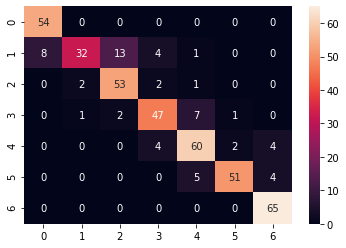

In [24]:
evaluation(knn)

# Create New attribute

In [25]:
IMC = df["Weight"]/((df["Height"])**2)
df.insert(loc = 4, column='IMC', value=IMC)

In [26]:
X_train, Y_train, X_test, Y_test = GetReadyForML(df)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [ ]:
# pd.DataFrame(rf.feature_importances_, index=X_train.columns).plot.bar(figsize=(8, 5),alpha=.6,color='black',  edgecolor='black')

Learning rate set to 0.081268
0:	learn: 1.6048682	total: 19.5ms	remaining: 19.5s
1:	learn: 1.4150744	total: 44.7ms	remaining: 22.3s
2:	learn: 1.2994458	total: 64.1ms	remaining: 21.3s
3:	learn: 1.1332355	total: 80.4ms	remaining: 20s
4:	learn: 1.0061591	total: 96.2ms	remaining: 19.1s
5:	learn: 0.9216093	total: 112ms	remaining: 18.6s
6:	learn: 0.8255849	total: 128ms	remaining: 18.2s
7:	learn: 0.7553712	total: 144ms	remaining: 17.8s
8:	learn: 0.6917593	total: 160ms	remaining: 17.6s
9:	learn: 0.6401351	total: 175ms	remaining: 17.4s
10:	learn: 0.5959475	total: 191ms	remaining: 17.2s
11:	learn: 0.5571097	total: 210ms	remaining: 17.3s
12:	learn: 0.5163191	total: 227ms	remaining: 17.3s
13:	learn: 0.4910807	total: 243ms	remaining: 17.1s
14:	learn: 0.4572210	total: 259ms	remaining: 17s
15:	learn: 0.4289312	total: 275ms	remaining: 16.9s
16:	learn: 0.4033919	total: 290ms	remaining: 16.8s
17:	learn: 0.3762713	total: 307ms	remaining: 16.7s
18:	learn: 0.3546986	total: 323ms	remaining: 16.7s
19:	learn:

163:	learn: 0.0375926	total: 2.76s	remaining: 14.1s
164:	learn: 0.0374268	total: 2.78s	remaining: 14.1s
165:	learn: 0.0371818	total: 2.8s	remaining: 14.1s
166:	learn: 0.0369101	total: 2.81s	remaining: 14s
167:	learn: 0.0365860	total: 2.83s	remaining: 14s
168:	learn: 0.0362889	total: 2.84s	remaining: 14s
169:	learn: 0.0359789	total: 2.86s	remaining: 14s
170:	learn: 0.0357904	total: 2.88s	remaining: 13.9s
171:	learn: 0.0355876	total: 2.89s	remaining: 13.9s
172:	learn: 0.0352935	total: 2.91s	remaining: 13.9s
173:	learn: 0.0352105	total: 2.92s	remaining: 13.9s
174:	learn: 0.0349781	total: 2.94s	remaining: 13.9s
175:	learn: 0.0346464	total: 2.96s	remaining: 13.9s
176:	learn: 0.0344120	total: 2.97s	remaining: 13.8s
177:	learn: 0.0342259	total: 2.99s	remaining: 13.8s
178:	learn: 0.0339465	total: 3s	remaining: 13.8s
179:	learn: 0.0338293	total: 3.02s	remaining: 13.8s
180:	learn: 0.0334944	total: 3.04s	remaining: 13.7s
181:	learn: 0.0332744	total: 3.05s	remaining: 13.7s
182:	learn: 0.0329400	to

331:	learn: 0.0161602	total: 5.71s	remaining: 11.5s
332:	learn: 0.0161274	total: 5.73s	remaining: 11.5s
333:	learn: 0.0160747	total: 5.75s	remaining: 11.5s
334:	learn: 0.0160131	total: 5.76s	remaining: 11.4s
335:	learn: 0.0159706	total: 5.78s	remaining: 11.4s
336:	learn: 0.0158922	total: 5.8s	remaining: 11.4s
337:	learn: 0.0158415	total: 5.81s	remaining: 11.4s
338:	learn: 0.0157765	total: 5.83s	remaining: 11.4s
339:	learn: 0.0157168	total: 5.85s	remaining: 11.4s
340:	learn: 0.0156407	total: 5.87s	remaining: 11.4s
341:	learn: 0.0156075	total: 5.9s	remaining: 11.3s
342:	learn: 0.0155781	total: 5.92s	remaining: 11.3s
343:	learn: 0.0155146	total: 5.94s	remaining: 11.3s
344:	learn: 0.0154515	total: 5.96s	remaining: 11.3s
345:	learn: 0.0153805	total: 5.98s	remaining: 11.3s
346:	learn: 0.0153352	total: 6s	remaining: 11.3s
347:	learn: 0.0152945	total: 6.02s	remaining: 11.3s
348:	learn: 0.0152630	total: 6.03s	remaining: 11.3s
349:	learn: 0.0152028	total: 6.05s	remaining: 11.2s
350:	learn: 0.015

492:	learn: 0.0101642	total: 8.46s	remaining: 8.7s
493:	learn: 0.0101391	total: 8.47s	remaining: 8.68s
494:	learn: 0.0101164	total: 8.49s	remaining: 8.66s
495:	learn: 0.0101070	total: 8.51s	remaining: 8.64s
496:	learn: 0.0100840	total: 8.52s	remaining: 8.63s
497:	learn: 0.0100591	total: 8.54s	remaining: 8.61s
498:	learn: 0.0100309	total: 8.55s	remaining: 8.59s
499:	learn: 0.0100132	total: 8.57s	remaining: 8.57s
500:	learn: 0.0099758	total: 8.59s	remaining: 8.55s
501:	learn: 0.0099593	total: 8.6s	remaining: 8.54s
502:	learn: 0.0099407	total: 8.62s	remaining: 8.52s
503:	learn: 0.0099181	total: 8.64s	remaining: 8.5s
504:	learn: 0.0098930	total: 8.66s	remaining: 8.48s
505:	learn: 0.0098561	total: 8.67s	remaining: 8.47s
506:	learn: 0.0098329	total: 8.69s	remaining: 8.45s
507:	learn: 0.0098115	total: 8.71s	remaining: 8.43s
508:	learn: 0.0097837	total: 8.72s	remaining: 8.41s
509:	learn: 0.0097645	total: 8.74s	remaining: 8.4s
510:	learn: 0.0097428	total: 8.76s	remaining: 8.38s
511:	learn: 0.00

658:	learn: 0.0071484	total: 11.2s	remaining: 5.8s
659:	learn: 0.0071434	total: 11.2s	remaining: 5.79s
660:	learn: 0.0071288	total: 11.3s	remaining: 5.77s
661:	learn: 0.0071030	total: 11.3s	remaining: 5.75s
662:	learn: 0.0070946	total: 11.3s	remaining: 5.74s
663:	learn: 0.0070846	total: 11.3s	remaining: 5.72s
664:	learn: 0.0070736	total: 11.3s	remaining: 5.7s
665:	learn: 0.0070603	total: 11.3s	remaining: 5.69s
666:	learn: 0.0070332	total: 11.4s	remaining: 5.67s
667:	learn: 0.0070073	total: 11.4s	remaining: 5.66s
668:	learn: 0.0069975	total: 11.4s	remaining: 5.64s
669:	learn: 0.0069902	total: 11.4s	remaining: 5.63s
670:	learn: 0.0069543	total: 11.4s	remaining: 5.61s
671:	learn: 0.0069361	total: 11.5s	remaining: 5.59s
672:	learn: 0.0069188	total: 11.5s	remaining: 5.58s
673:	learn: 0.0069045	total: 11.5s	remaining: 5.56s
674:	learn: 0.0068982	total: 11.5s	remaining: 5.54s
675:	learn: 0.0068855	total: 11.5s	remaining: 5.52s
676:	learn: 0.0068709	total: 11.5s	remaining: 5.51s
677:	learn: 0.

822:	learn: 0.0054359	total: 14s	remaining: 3.01s
823:	learn: 0.0054272	total: 14s	remaining: 3s
824:	learn: 0.0054198	total: 14.1s	remaining: 2.98s
825:	learn: 0.0054145	total: 14.1s	remaining: 2.96s
826:	learn: 0.0054069	total: 14.1s	remaining: 2.95s
827:	learn: 0.0053976	total: 14.1s	remaining: 2.93s
828:	learn: 0.0053946	total: 14.1s	remaining: 2.91s
829:	learn: 0.0053865	total: 14.1s	remaining: 2.9s
830:	learn: 0.0053816	total: 14.2s	remaining: 2.88s
831:	learn: 0.0053787	total: 14.2s	remaining: 2.86s
832:	learn: 0.0053703	total: 14.2s	remaining: 2.85s
833:	learn: 0.0053657	total: 14.2s	remaining: 2.83s
834:	learn: 0.0053607	total: 14.2s	remaining: 2.81s
835:	learn: 0.0053557	total: 14.2s	remaining: 2.79s
836:	learn: 0.0053451	total: 14.3s	remaining: 2.78s
837:	learn: 0.0053403	total: 14.3s	remaining: 2.76s
838:	learn: 0.0053344	total: 14.3s	remaining: 2.75s
839:	learn: 0.0053280	total: 14.4s	remaining: 2.73s
840:	learn: 0.0053179	total: 14.4s	remaining: 2.73s
841:	learn: 0.005315

982:	learn: 0.0043987	total: 17.4s	remaining: 302ms
983:	learn: 0.0043966	total: 17.5s	remaining: 284ms
984:	learn: 0.0043917	total: 17.5s	remaining: 266ms
985:	learn: 0.0043867	total: 17.5s	remaining: 248ms
986:	learn: 0.0043720	total: 17.5s	remaining: 231ms
987:	learn: 0.0043683	total: 17.5s	remaining: 213ms
988:	learn: 0.0043645	total: 17.5s	remaining: 195ms
989:	learn: 0.0043588	total: 17.6s	remaining: 177ms
990:	learn: 0.0043542	total: 17.6s	remaining: 160ms
991:	learn: 0.0043489	total: 17.6s	remaining: 142ms
992:	learn: 0.0043424	total: 17.6s	remaining: 124ms
993:	learn: 0.0043386	total: 17.6s	remaining: 107ms
994:	learn: 0.0043334	total: 17.7s	remaining: 88.8ms
995:	learn: 0.0043286	total: 17.7s	remaining: 71.1ms
996:	learn: 0.0043245	total: 17.7s	remaining: 53.3ms
997:	learn: 0.0043175	total: 17.8s	remaining: 35.6ms
998:	learn: 0.0043138	total: 17.8s	remaining: 17.8ms
999:	learn: 0.0043094	total: 17.8s	remaining: 0us
              precision    recall  f1-score   support

      

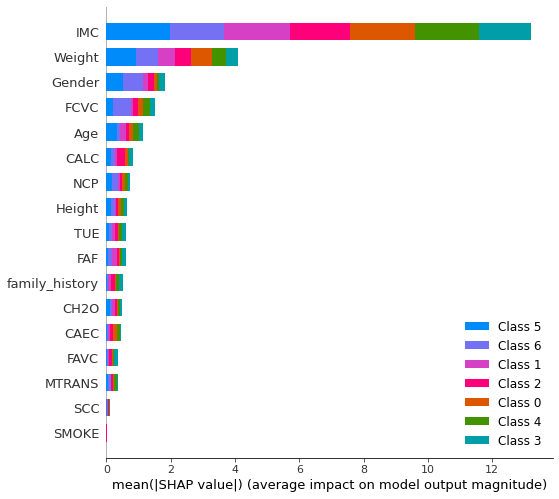

In [27]:
catboost()

Test Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        58
           2       0.98      1.00      0.99        58
           3       1.00      0.98      0.99        58
           4       1.00      0.99      0.99        70
           5       0.98      1.00      0.99        60
           6       1.00      1.00      1.00        65

    accuracy                           1.00       423
   macro avg       1.00      1.00      1.00       423
weighted avg       1.00      1.00      1.00       423

Accuracy : 0.9952718676122931
F1_score : 0.9952729569439465
Recall : 0.9952718676122931
pression : 0.9953506917143387


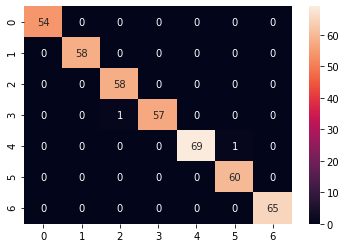

In [29]:
evaluation(rf)

Test Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      0.98      0.99        58
           2       0.95      0.95      0.95        58
           3       0.93      0.97      0.95        58
           4       1.00      0.97      0.99        70
           5       0.98      1.00      0.99        60
           6       1.00      1.00      1.00        65

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423

Accuracy : 0.9810874704491725
F1_score : 0.9811729056957965
Recall : 0.9810874704491725
pression : 0.9814414344585254


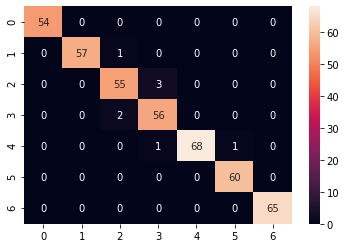

In [30]:
evaluation(dt)

Test Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.98      0.98      0.98        58
           2       0.96      0.93      0.95        58
           3       0.93      0.97      0.95        58
           4       0.99      0.96      0.97        70
           5       0.97      1.00      0.98        60
           6       1.00      1.00      1.00        65

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423

Accuracy : 0.9763593380614657
F1_score : 0.9763253518062797
Recall : 0.9763593380614657
pression : 0.9765886740572841


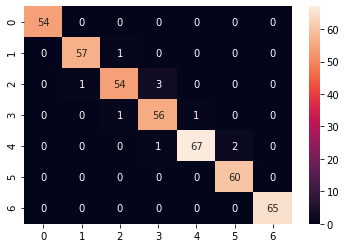

In [31]:
evaluation(gb)

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Test Data
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        54
           1       0.51      0.98      0.67        58
           2       0.00      0.00      0.00        58
           3       0.49      0.98      0.66        58
           4       0.35      0.99      0.52        70
           5       0.00      0.00      0.00        60
           6       0.00      0.00      0.00        65

    accuracy                           0.43       423
   macro avg       0.19      0.42      0.26       423
weighted avg       0.20      0.43      0.27       423

Accuracy : 0.4326241134751773
F1_score : 0.2679596875549364
Recall : 0.4326241134751773
pression : 0.1957141558205388


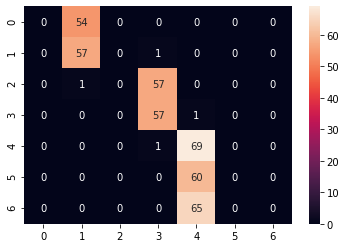

In [32]:
evaluation(ad)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Test Data
              precision    recall  f1-score   support

           0       0.84      0.85      0.84        54
           1       0.63      0.62      0.63        58
           2       0.58      0.48      0.53        58
           3       0.53      0.59      0.56        58
           4       0.54      0.53      0.54        70
           5       0.70      0.72      0.71        60
           6       0.79      0.85      0.81        65

    accuracy                           0.66       423
   macro avg       0.66      0.66      0.66       423
weighted avg       0.66      0.66      0.66       423

Accuracy : 0.6595744680851063
F1_score : 0.6572203932913777
Recall : 0.6595744680851063
pression : 0.6569640531373463


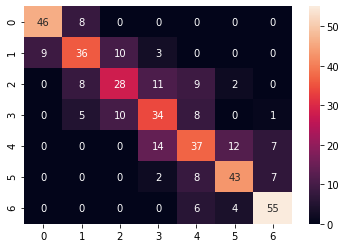

In [33]:
evaluation(lg)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


[19:29:11] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Test Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      0.98      0.99        58
           2       0.96      0.95      0.96        58
           3       0.95      0.98      0.97        58
           4       1.00      1.00      1.00        70
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        65

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423

Accuracy : 0.9881796690307328
F1_score : 0.988198135575799
Recall : 0.988179669030

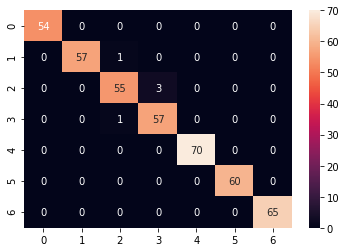

In [34]:
evaluation(xg)

Test Data
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        54
           1       1.00      0.74      0.85        58
           2       0.84      1.00      0.91        58
           3       0.98      0.91      0.95        58
           4       0.93      0.97      0.95        70
           5       0.98      0.90      0.94        60
           6       0.93      1.00      0.96        65

    accuracy                           0.93       423
   macro avg       0.94      0.93      0.93       423
weighted avg       0.94      0.93      0.93       423

Accuracy : 0.933806146572104
F1_score : 0.932340043573231
Recall : 0.933806146572104
pression : 0.9398935960902591


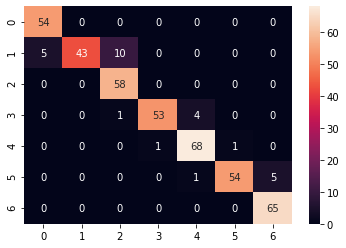

In [35]:
evaluation(knn)

# Drop Height and Weight

In [36]:
df = data.copy()
df = df.rename(columns={'family_history_with_overweight': 'family_history'})
df = df.drop('Weight',axis = 1)
df = df.drop('Height',axis = 1)

X_train, Y_train, X_test, Y_test = GetReadyForML(df)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Learning rate set to 0.081268
0:	learn: 1.8167165	total: 14.8ms	remaining: 14.8s
1:	learn: 1.7209131	total: 33.8ms	remaining: 16.9s
2:	learn: 1.6325823	total: 49.3ms	remaining: 16.4s
3:	learn: 1.5717782	total: 64.6ms	remaining: 16.1s
4:	learn: 1.5086794	total: 76.1ms	remaining: 15.2s
5:	learn: 1.4532656	total: 87.6ms	remaining: 14.5s
6:	learn: 1.4067725	total: 98.9ms	remaining: 14s
7:	learn: 1.3611248	total: 110ms	remaining: 13.7s
8:	learn: 1.3216707	total: 121ms	remaining: 13.4s
9:	learn: 1.2830885	total: 133ms	remaining: 13.1s
10:	learn: 1.2463236	total: 144ms	remaining: 12.9s
11:	learn: 1.2141917	total: 155ms	remaining: 12.8s
12:	learn: 1.1837904	total: 166ms	remaining: 12.6s
13:	learn: 1.1546820	total: 178ms	remaining: 12.5s
14:	learn: 1.1333996	total: 189ms	remaining: 12.4s
15:	learn: 1.1107252	total: 202ms	remaining: 12.4s
16:	learn: 1.0872472	total: 214ms	remaining: 12.4s
17:	learn: 1.0662263	total: 226ms	remaining: 12.3s
18:	learn: 1.0434315	total: 237ms	remaining: 12.3s
19:	le

162:	learn: 0.3598377	total: 2s	remaining: 10.3s
163:	learn: 0.3588454	total: 2.01s	remaining: 10.2s
164:	learn: 0.3568472	total: 2.02s	remaining: 10.2s
165:	learn: 0.3553262	total: 2.03s	remaining: 10.2s
166:	learn: 0.3531287	total: 2.05s	remaining: 10.2s
167:	learn: 0.3518305	total: 2.06s	remaining: 10.2s
168:	learn: 0.3507141	total: 2.07s	remaining: 10.2s
169:	learn: 0.3493002	total: 2.08s	remaining: 10.2s
170:	learn: 0.3479522	total: 2.1s	remaining: 10.2s
171:	learn: 0.3463163	total: 2.11s	remaining: 10.2s
172:	learn: 0.3448696	total: 2.12s	remaining: 10.1s
173:	learn: 0.3434684	total: 2.13s	remaining: 10.1s
174:	learn: 0.3414294	total: 2.14s	remaining: 10.1s
175:	learn: 0.3392484	total: 2.16s	remaining: 10.1s
176:	learn: 0.3380859	total: 2.17s	remaining: 10.1s
177:	learn: 0.3358786	total: 2.18s	remaining: 10.1s
178:	learn: 0.3341509	total: 2.19s	remaining: 10.1s
179:	learn: 0.3329487	total: 2.21s	remaining: 10.1s
180:	learn: 0.3308477	total: 2.22s	remaining: 10s
181:	learn: 0.3293

326:	learn: 0.2005756	total: 4s	remaining: 8.23s
327:	learn: 0.2000968	total: 4.01s	remaining: 8.22s
328:	learn: 0.1995331	total: 4.03s	remaining: 8.21s
329:	learn: 0.1990743	total: 4.04s	remaining: 8.2s
330:	learn: 0.1981248	total: 4.05s	remaining: 8.19s
331:	learn: 0.1973977	total: 4.06s	remaining: 8.18s
332:	learn: 0.1969874	total: 4.08s	remaining: 8.17s
333:	learn: 0.1965239	total: 4.09s	remaining: 8.16s
334:	learn: 0.1955839	total: 4.1s	remaining: 8.14s
335:	learn: 0.1951525	total: 4.11s	remaining: 8.13s
336:	learn: 0.1948791	total: 4.13s	remaining: 8.12s
337:	learn: 0.1942493	total: 4.14s	remaining: 8.11s
338:	learn: 0.1936388	total: 4.15s	remaining: 8.1s
339:	learn: 0.1931886	total: 4.17s	remaining: 8.09s
340:	learn: 0.1927251	total: 4.18s	remaining: 8.07s
341:	learn: 0.1922708	total: 4.19s	remaining: 8.06s
342:	learn: 0.1915672	total: 4.2s	remaining: 8.05s
343:	learn: 0.1911150	total: 4.22s	remaining: 8.04s
344:	learn: 0.1903489	total: 4.23s	remaining: 8.03s
345:	learn: 0.18995

487:	learn: 0.1350838	total: 6s	remaining: 6.29s
488:	learn: 0.1347878	total: 6.01s	remaining: 6.28s
489:	learn: 0.1344402	total: 6.03s	remaining: 6.27s
490:	learn: 0.1342987	total: 6.04s	remaining: 6.26s
491:	learn: 0.1338744	total: 6.05s	remaining: 6.25s
492:	learn: 0.1336818	total: 6.07s	remaining: 6.24s
493:	learn: 0.1333690	total: 6.08s	remaining: 6.22s
494:	learn: 0.1330102	total: 6.09s	remaining: 6.21s
495:	learn: 0.1327099	total: 6.1s	remaining: 6.2s
496:	learn: 0.1325067	total: 6.11s	remaining: 6.19s
497:	learn: 0.1323221	total: 6.12s	remaining: 6.17s
498:	learn: 0.1320677	total: 6.14s	remaining: 6.16s
499:	learn: 0.1318386	total: 6.15s	remaining: 6.15s
500:	learn: 0.1315574	total: 6.16s	remaining: 6.13s
501:	learn: 0.1313280	total: 6.17s	remaining: 6.12s
502:	learn: 0.1311751	total: 6.19s	remaining: 6.11s
503:	learn: 0.1306609	total: 6.2s	remaining: 6.1s
504:	learn: 0.1303619	total: 6.21s	remaining: 6.09s
505:	learn: 0.1300284	total: 6.22s	remaining: 6.07s
506:	learn: 0.12980

651:	learn: 0.0985498	total: 7.99s	remaining: 4.26s
652:	learn: 0.0984272	total: 8s	remaining: 4.25s
653:	learn: 0.0982359	total: 8.02s	remaining: 4.24s
654:	learn: 0.0980630	total: 8.03s	remaining: 4.23s
655:	learn: 0.0978588	total: 8.04s	remaining: 4.22s
656:	learn: 0.0977448	total: 8.05s	remaining: 4.2s
657:	learn: 0.0976003	total: 8.06s	remaining: 4.19s
658:	learn: 0.0973669	total: 8.07s	remaining: 4.18s
659:	learn: 0.0971365	total: 8.09s	remaining: 4.17s
660:	learn: 0.0970267	total: 8.1s	remaining: 4.15s
661:	learn: 0.0968538	total: 8.11s	remaining: 4.14s
662:	learn: 0.0966510	total: 8.12s	remaining: 4.13s
663:	learn: 0.0964725	total: 8.13s	remaining: 4.11s
664:	learn: 0.0963617	total: 8.14s	remaining: 4.1s
665:	learn: 0.0962146	total: 8.15s	remaining: 4.09s
666:	learn: 0.0961246	total: 8.17s	remaining: 4.08s
667:	learn: 0.0959927	total: 8.18s	remaining: 4.07s
668:	learn: 0.0958119	total: 8.2s	remaining: 4.06s
669:	learn: 0.0956388	total: 8.21s	remaining: 4.04s
670:	learn: 0.09552

816:	learn: 0.0757619	total: 9.98s	remaining: 2.23s
817:	learn: 0.0756940	total: 9.99s	remaining: 2.22s
818:	learn: 0.0756068	total: 10s	remaining: 2.21s
819:	learn: 0.0753804	total: 10s	remaining: 2.2s
820:	learn: 0.0752754	total: 10s	remaining: 2.19s
821:	learn: 0.0751776	total: 10s	remaining: 2.17s
822:	learn: 0.0750976	total: 10.1s	remaining: 2.16s
823:	learn: 0.0749813	total: 10.1s	remaining: 2.15s
824:	learn: 0.0748954	total: 10.1s	remaining: 2.14s
825:	learn: 0.0747058	total: 10.1s	remaining: 2.13s
826:	learn: 0.0746136	total: 10.1s	remaining: 2.12s
827:	learn: 0.0745010	total: 10.1s	remaining: 2.11s
828:	learn: 0.0743411	total: 10.2s	remaining: 2.09s
829:	learn: 0.0742175	total: 10.2s	remaining: 2.08s
830:	learn: 0.0741240	total: 10.2s	remaining: 2.07s
831:	learn: 0.0740439	total: 10.2s	remaining: 2.06s
832:	learn: 0.0739672	total: 10.2s	remaining: 2.05s
833:	learn: 0.0738611	total: 10.2s	remaining: 2.04s
834:	learn: 0.0736754	total: 10.2s	remaining: 2.02s
835:	learn: 0.0736104

985:	learn: 0.0601184	total: 12.2s	remaining: 173ms
986:	learn: 0.0600575	total: 12.2s	remaining: 160ms
987:	learn: 0.0599917	total: 12.2s	remaining: 148ms
988:	learn: 0.0599133	total: 12.2s	remaining: 136ms
989:	learn: 0.0598372	total: 12.2s	remaining: 123ms
990:	learn: 0.0597756	total: 12.2s	remaining: 111ms
991:	learn: 0.0596823	total: 12.2s	remaining: 98.6ms
992:	learn: 0.0596169	total: 12.2s	remaining: 86.3ms
993:	learn: 0.0595568	total: 12.3s	remaining: 74ms
994:	learn: 0.0595013	total: 12.3s	remaining: 61.7ms
995:	learn: 0.0593931	total: 12.3s	remaining: 49.3ms
996:	learn: 0.0593387	total: 12.3s	remaining: 37ms
997:	learn: 0.0592757	total: 12.3s	remaining: 24.7ms
998:	learn: 0.0592057	total: 12.3s	remaining: 12.3ms
999:	learn: 0.0590841	total: 12.3s	remaining: 0us
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        54
           1       0.74      0.69      0.71        58
           2       0.87      0.79      0.83        58
 

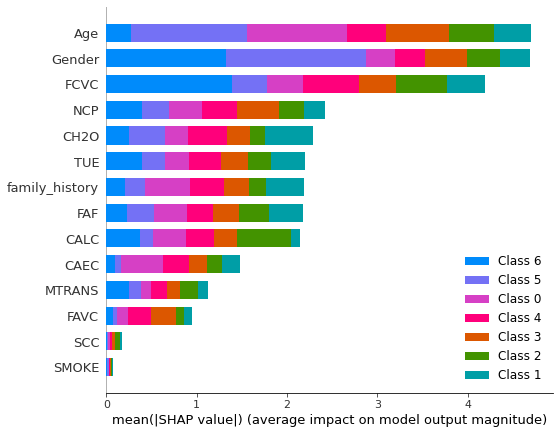

In [37]:
catboost()

Test Data
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        54
           1       0.77      0.83      0.80        58
           2       0.94      0.76      0.84        58
           3       0.89      0.83      0.86        58
           4       0.80      0.87      0.84        70
           5       0.89      0.98      0.94        60
           6       1.00      1.00      1.00        65

    accuracy                           0.88       423
   macro avg       0.88      0.88      0.88       423
weighted avg       0.88      0.88      0.88       423

Accuracy : 0.8794326241134752
F1_score : 0.8790701861363259
Recall : 0.8794326241134752
pression : 0.8828936650542372


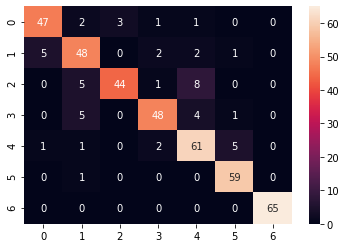

In [39]:
evaluation(rf)

Test Data
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        54
           1       0.50      0.48      0.49        58
           2       0.73      0.69      0.71        58
           3       0.65      0.64      0.64        58
           4       0.69      0.81      0.75        70
           5       0.88      0.85      0.86        60
           6       0.98      1.00      0.99        65

    accuracy                           0.75       423
   macro avg       0.75      0.74      0.74       423
weighted avg       0.75      0.75      0.75       423

Accuracy : 0.7494089834515366
F1_score : 0.7486858583190924
Recall : 0.7494089834515366
pression : 0.7507139535467351


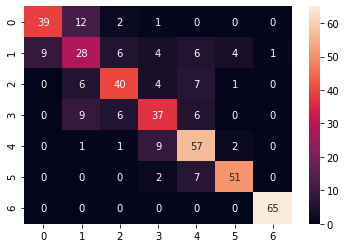

In [40]:
evaluation(dt)

Test Data
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        54
           1       0.75      0.67      0.71        58
           2       0.78      0.72      0.75        58
           3       0.83      0.60      0.70        58
           4       0.69      0.84      0.76        70
           5       0.84      0.98      0.91        60
           6       1.00      1.00      1.00        65

    accuracy                           0.82       423
   macro avg       0.82      0.81      0.81       423
weighted avg       0.82      0.82      0.81       423

Accuracy : 0.8156028368794326
F1_score : 0.812381865573355
Recall : 0.8156028368794326
pression : 0.8192414393140106


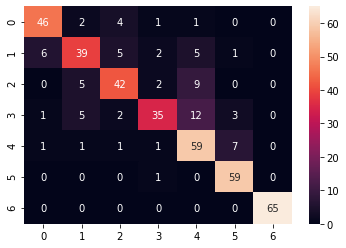

In [41]:
evaluation(gb)

Test Data
              precision    recall  f1-score   support

           0       0.74      0.31      0.44        54
           1       0.67      0.24      0.35        58
           2       0.67      0.07      0.12        58
           3       0.18      0.03      0.06        58
           4       0.23      0.53      0.32        70
           5       0.29      0.63      0.40        60
           6       0.90      1.00      0.95        65

    accuracy                           0.42       423
   macro avg       0.53      0.40      0.38       423
weighted avg       0.52      0.42      0.39       423

Accuracy : 0.41843971631205673
F1_score : 0.38578416480572836
Recall : 0.41843971631205673
pression : 0.5204876483247675


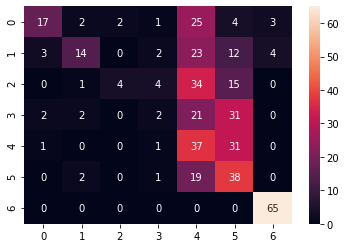

In [42]:
evaluation(ad)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Test Data
              precision    recall  f1-score   support

           0       0.64      0.56      0.59        54
           1       0.60      0.31      0.41        58
           2       0.40      0.29      0.34        58
           3       0.40      0.10      0.16        58
           4       0.45      0.63      0.52        70
           5       0.51      0.88      0.65        60
           6       0.75      1.00      0.86        65

    accuracy                           0.55       423
   macro avg       0.53      0.54      0.50       423
weighted avg       0.53      0.55      0.51       423

Accuracy : 0.5508274231678487
F1_score : 0.5109755473675054
Recall : 0.5508274231678487
pression : 0.5349028224389256


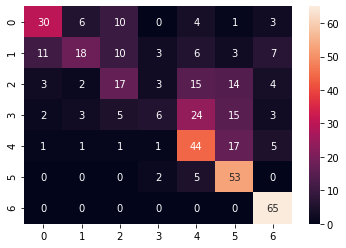

In [43]:
evaluation(lg)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


[19:30:42] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Test Data
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        54
           1       0.74      0.78      0.76        58
           2       0.84      0.74      0.79        58
           3       0.85      0.76      0.80        58
           4       0.79      0.89      0.84        70
           5       0.89      0.98      0.94        60
           6       1.00      1.00      1.00        65

    accuracy                           0.85       423
   macro avg       0.85      0.85      0.85       423
weighted avg       0.85      0.85      0.85       423

Accuracy : 0.8534278959810875
F1_score : 0.8522931089866824
Recall : 0.85342789598

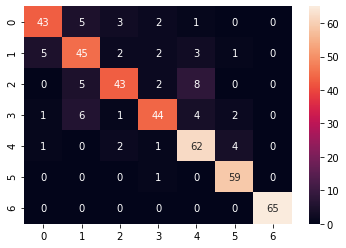

In [44]:
evaluation(xg)

Test Data
              precision    recall  f1-score   support

           0       0.76      0.93      0.83        54
           1       0.68      0.22      0.34        58
           2       0.63      0.64      0.63        58
           3       0.81      0.59      0.68        58
           4       0.70      0.81      0.75        70
           5       0.74      1.00      0.85        60
           6       0.88      1.00      0.94        65

    accuracy                           0.75       423
   macro avg       0.74      0.74      0.72       423
weighted avg       0.74      0.75      0.72       423

Accuracy : 0.7470449172576832
F1_score : 0.7211900070020926
Recall : 0.7470449172576832
pression : 0.7425913460239355


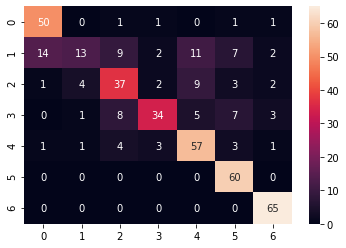

In [45]:
evaluation(knn)